# Price Monitor — EDA, feature engineering and machine learning

This notebook is the readable entry point to the reproducible research pipeline. It validates the local snapshot, builds causal historical features, compares transparent baselines with three ML families using purged chronological validation, calibrates uncertainty on a separate period, and evaluates once on a frozen final holdout.

The production API continues to use its lightweight Holt baseline. Research results are not promoted automatically.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'price_monitor').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'data' / 'processed' / 'market_prices.csv'
REPORTS = ROOT / 'reports' / 'data_science'
ROOT, DATA

(WindowsPath('C:/Users/thinkpad/Downloads/project_stage/repo_push'),
 WindowsPath('C:/Users/thinkpad/Downloads/project_stage/repo_push/data/processed/market_prices.csv'))

## 1. Rebuild the complete audit

This command is deterministic for a fixed snapshot and dependency set. Network access is not used. The pipeline writes machine-readable tables, figures, model cards, and a manifest with data/code fingerprints.

In [2]:
from price_monitor.analysis.pipeline import run_analysis
manifest = run_analysis(DATA, REPORTS, horizons=(1, 7, 30, 90), save_models=False)
display(pd.DataFrame(manifest['experiments'])[['product', 'horizon_days', 'selected_model', 'development_rows', 'calibration_rows', 'holdout_rows']])

Evaluating brent, 1 calendar day(s)...


Evaluating brent, 7 calendar day(s)...


Evaluating brent, 30 calendar day(s)...


Evaluating brent, 90 calendar day(s)...


Evaluating gasoil, 1 calendar day(s)...


Evaluating gasoil, 7 calendar day(s)...


Evaluating gasoil, 30 calendar day(s)...


Evaluating gasoil, 90 calendar day(s)...


,product,horizon_days,selected_model,development_rows,calibration_rows,holdout_rows
0,brent,1,naive,759,188,253
1,brent,7,naive,755,184,249
2,brent,30,naive,738,169,233
3,brent,90,naive,696,126,191
4,gasoil,1,naive,748,186,249
5,gasoil,7,naive,744,182,246
6,gasoil,30,naive,729,167,229
7,gasoil,90,naive,688,126,189


## 2. Data quality and EDA

The processed snapshot must match the bundled raw FRED CSVs. Missing weekdays include holidays and are not automatically treated as failures. Robust return outliers are review flags and remain in the data. Model diagnostics stop before calibration and holdout dates.

,unit,observations,missing_in_union_index,missing_weekdays_including_holidays,longest_gap_calendar_days,latest_source_date,age_calendar_days,raw_sha256,raw_mismatches
brent,USD/barrel,1263,24,41,5,2026-09-09,12,90b25160f3193d9c1440e8bb45e4fb621f69bb19a4c573...,0
gasoil,USD/gallon,1246,41,58,5,2026-09-09,12,e395d6cf1f84b3c174e932398e8c40a51376d3d900ce9d...,0


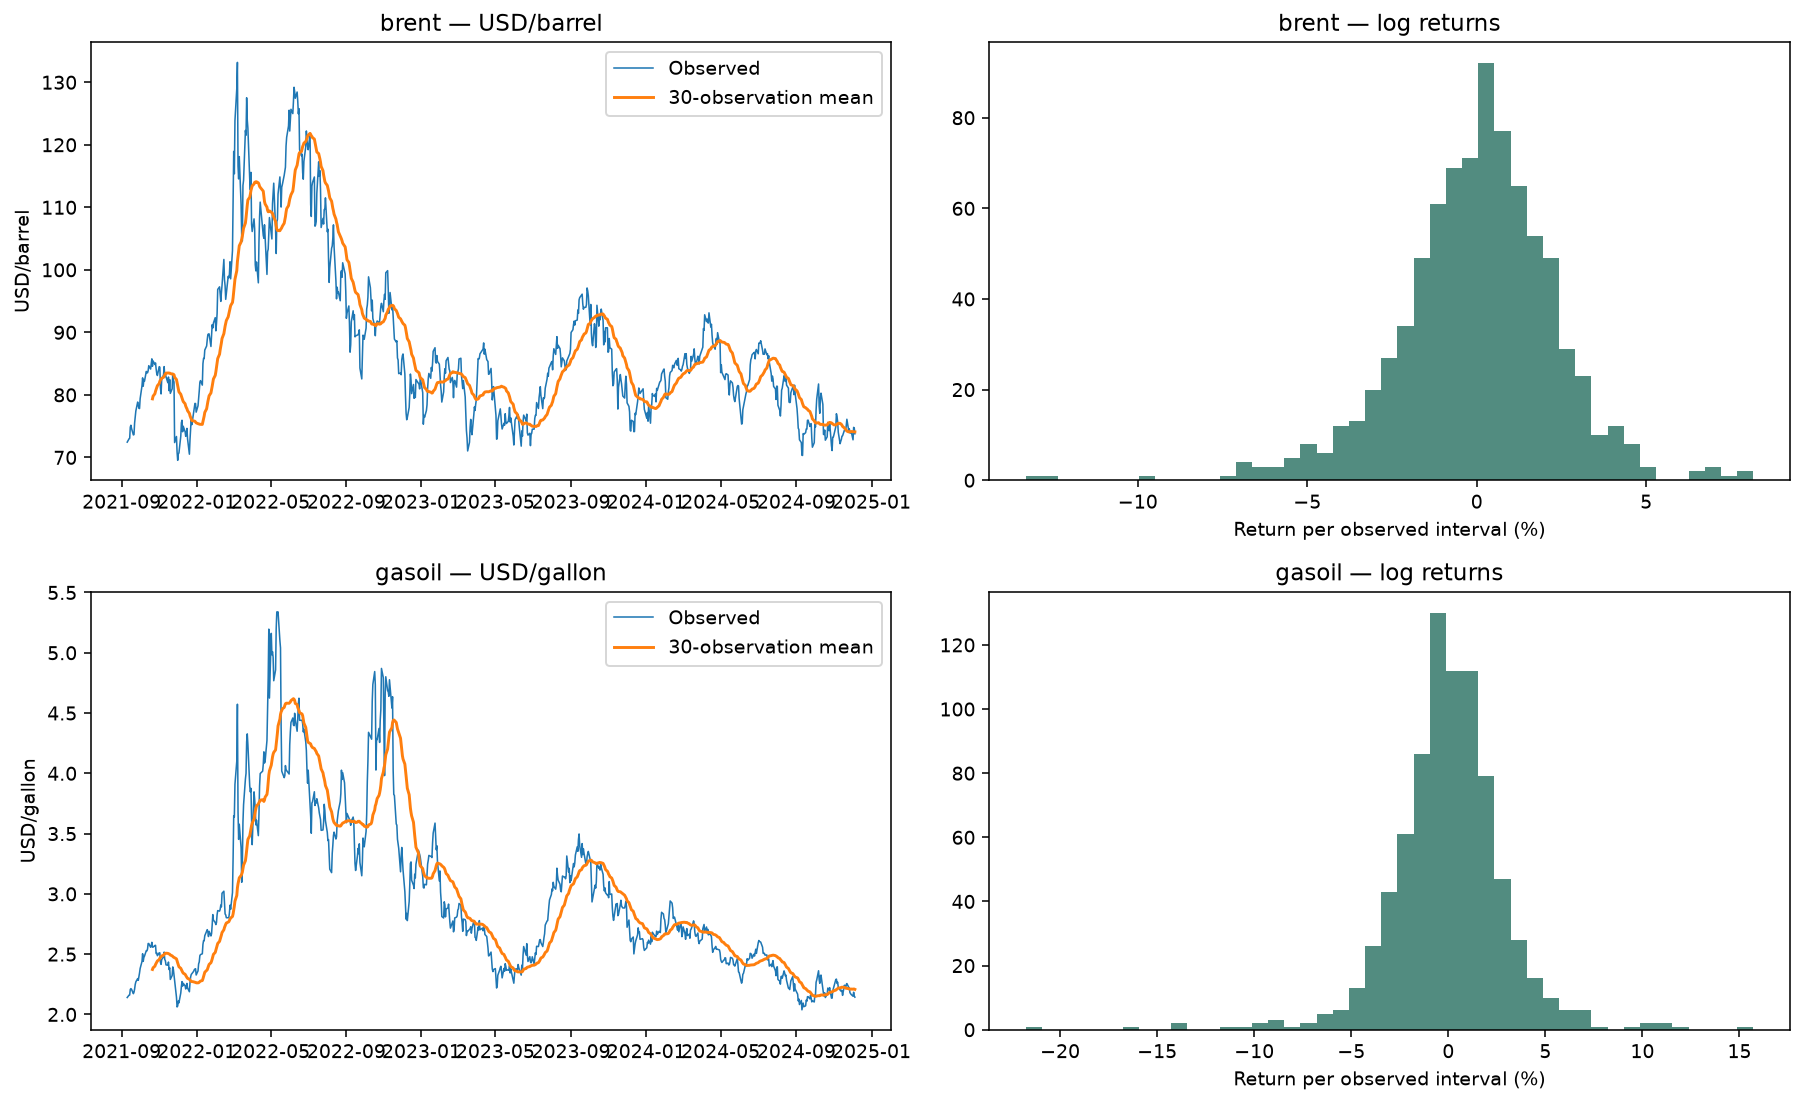

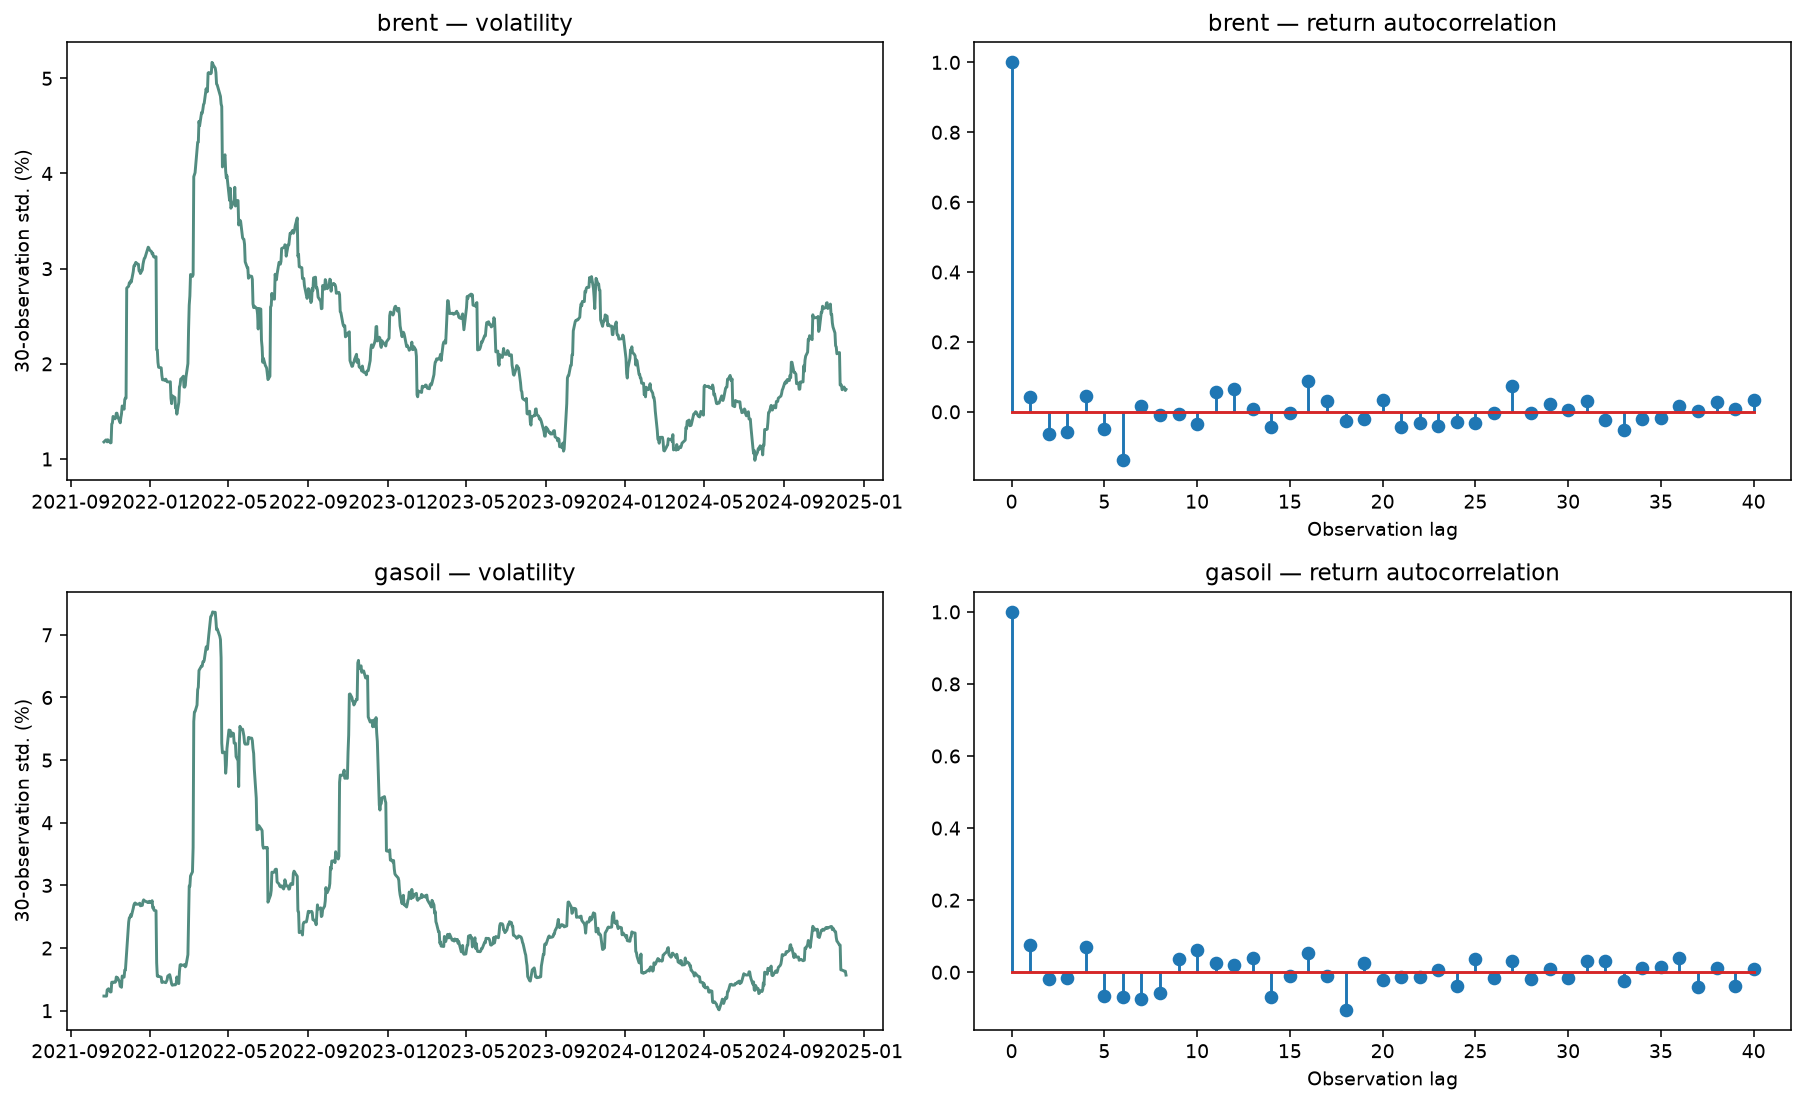

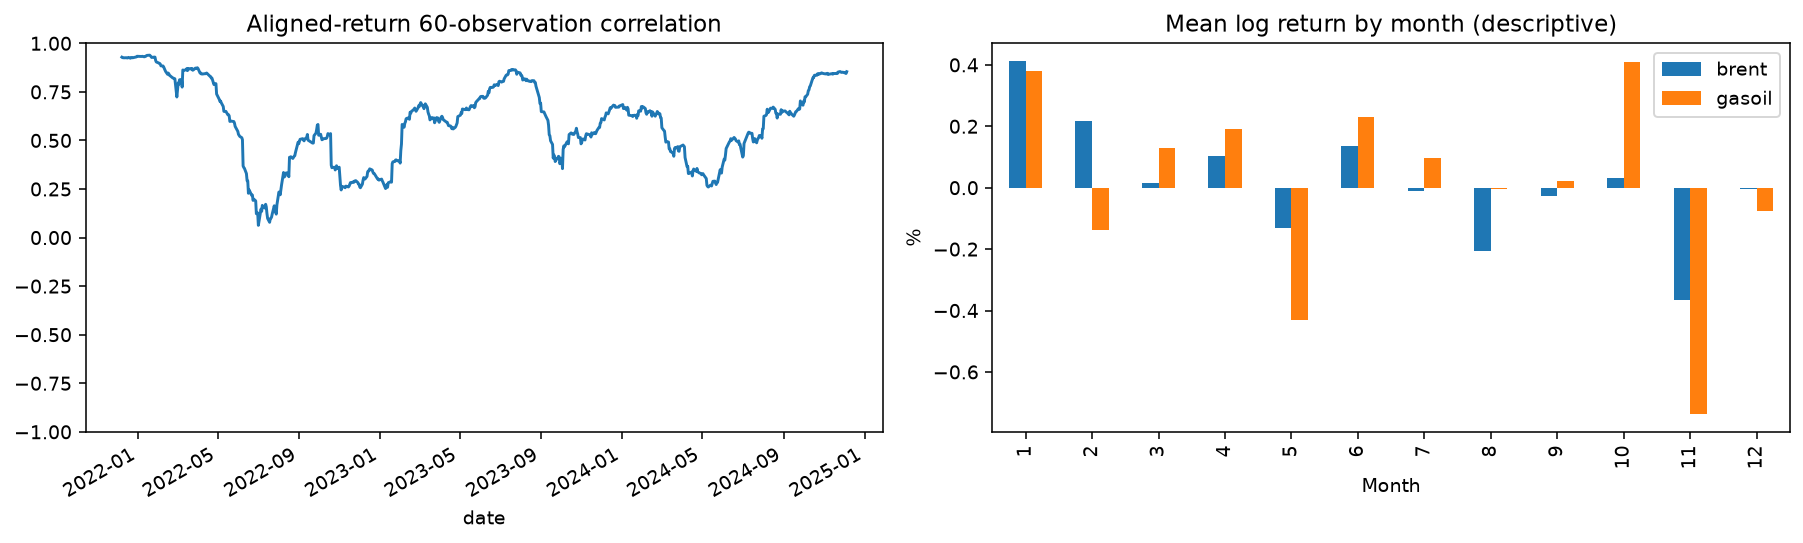

In [3]:
quality = json.loads((REPORTS / 'data_quality.json').read_text(encoding='utf-8'))
display(pd.DataFrame(quality['products']).T)
display(Image(filename=str(REPORTS / 'eda_prices_returns.png')))
display(Image(filename=str(REPORTS / 'eda_volatility_acf.png')))
display(Image(filename=str(REPORTS / 'eda_correlation_seasonality.png')))

## 3. Leakage-safe feature engineering

Features available at origin date *t* include the current own-product price; lagged log returns; rolling momentum, volatility and price ratios; calendar cycles; elapsed days; and only strictly earlier observations of the other product. Peer values older than seven days become missing. Targets are the first real publication on or after *t + horizon* and are never filled.

In [4]:
from price_monitor.analysis.data import load_market_data
from price_monitor.analysis.features import make_supervised
frame = load_market_data(DATA)
features, labels = make_supervised(frame, 'brent', horizon=30)
display(features.tail())
display(labels.tail())
print(f'{features.shape[1]} features; {len(features)} labeled origins; target delays: {sorted(labels.target_delay_days.unique())}')

,log_price,log_return_1,log_return_2,log_return_5,log_return_10,log_return_20,log_return_60,price_to_mean_5,volatility_5,momentum_5,...,weekday_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,peer_log_price,peer_log_return_1,peer_log_return_5,peer_age_days,relative_momentum_5
date,,,,,,,,,,,,,,,,,,,,,
2026-08-04,4.459798,-0.027715,-0.114398,0.011164,-0.081900,0.186192,-0.204679,-0.052238,0.063992,0.002233,...,0.623490,-0.5,-0.866025,-0.528581,-0.848883,1.360464,-0.065292,-0.051255,1.0,0.062419
2026-08-05,4.461877,0.002079,-0.025635,-0.059368,-0.082694,0.124586,-0.250981,-0.039101,0.051068,-0.011874,...,-0.222521,-0.5,-0.866025,-0.543105,-0.839665,1.323621,-0.036843,-0.102375,1.0,0.043007
2026-08-06,4.495913,0.034036,0.036116,-0.024897,-0.161090,0.185651,-0.207109,-0.000825,0.055161,-0.004979,...,-0.900969,-0.5,-0.866025,-0.557468,-0.830198,1.339989,0.016368,-0.147282,1.0,0.122385
2026-08-07,4.473009,-0.022904,0.011132,-0.101186,-0.135256,0.164360,-0.235710,-0.002709,0.044502,-0.020237,...,-0.900969,-0.5,-0.866025,-0.571667,-0.820486,1.377506,0.037517,-0.065877,1.0,-0.035309
2026-08-10,4.529800,0.056791,0.033887,0.042288,0.009970,0.127726,-0.206048,0.046420,0.036479,0.008458,...,1.000000,-0.5,-0.866025,-0.613230,-0.789905,1.363537,-0.013968,-0.062218,3.0,0.104506


,target_date,current_price,target_price,target_log_return,target_delay_days
date,,,,,
2026-08-04,2026-09-03,86.47,100.52,0.150559,0
2026-08-05,2026-09-04,86.65,102.24,0.165446,0
2026-08-06,2026-09-07,89.65,104.47,0.152987,2
2026-08-07,2026-09-07,87.62,104.47,0.175891,1
2026-08-10,2026-09-09,92.74,109.51,0.166216,0


28 features; 1182 labeled origins; target delays: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 4. Model comparison and final holdout

Candidates are persistence, corrected damped Holt, Ridge, histogram gradient boosting, and random forest. Model choice uses expanding-window validation only and requires a 2% MAE improvement over persistence. The next 15% of dates calibrate bands; the last 20% form the untouched holdout. Overlapping targets are purged from training.

,product,horizon_days,model,mae,rmse,mae_skill_vs_naive,interval_coverage
0,brent,1,naive,2.367747,3.655905,0.0,0.790514
8,brent,7,naive,5.436185,7.710908,0.0,0.871486
16,brent,30,naive,12.400858,17.824986,0.0,0.660944
24,brent,90,naive,23.841832,30.648966,0.0,0.523560
32,gasoil,1,naive,0.086614,0.125200,0.0,0.855422
40,gasoil,7,naive,0.186175,0.254845,0.0,0.861789
48,gasoil,30,naive,0.458672,0.630951,0.0,0.729258
56,gasoil,90,naive,0.779873,1.045913,0.0,0.566138


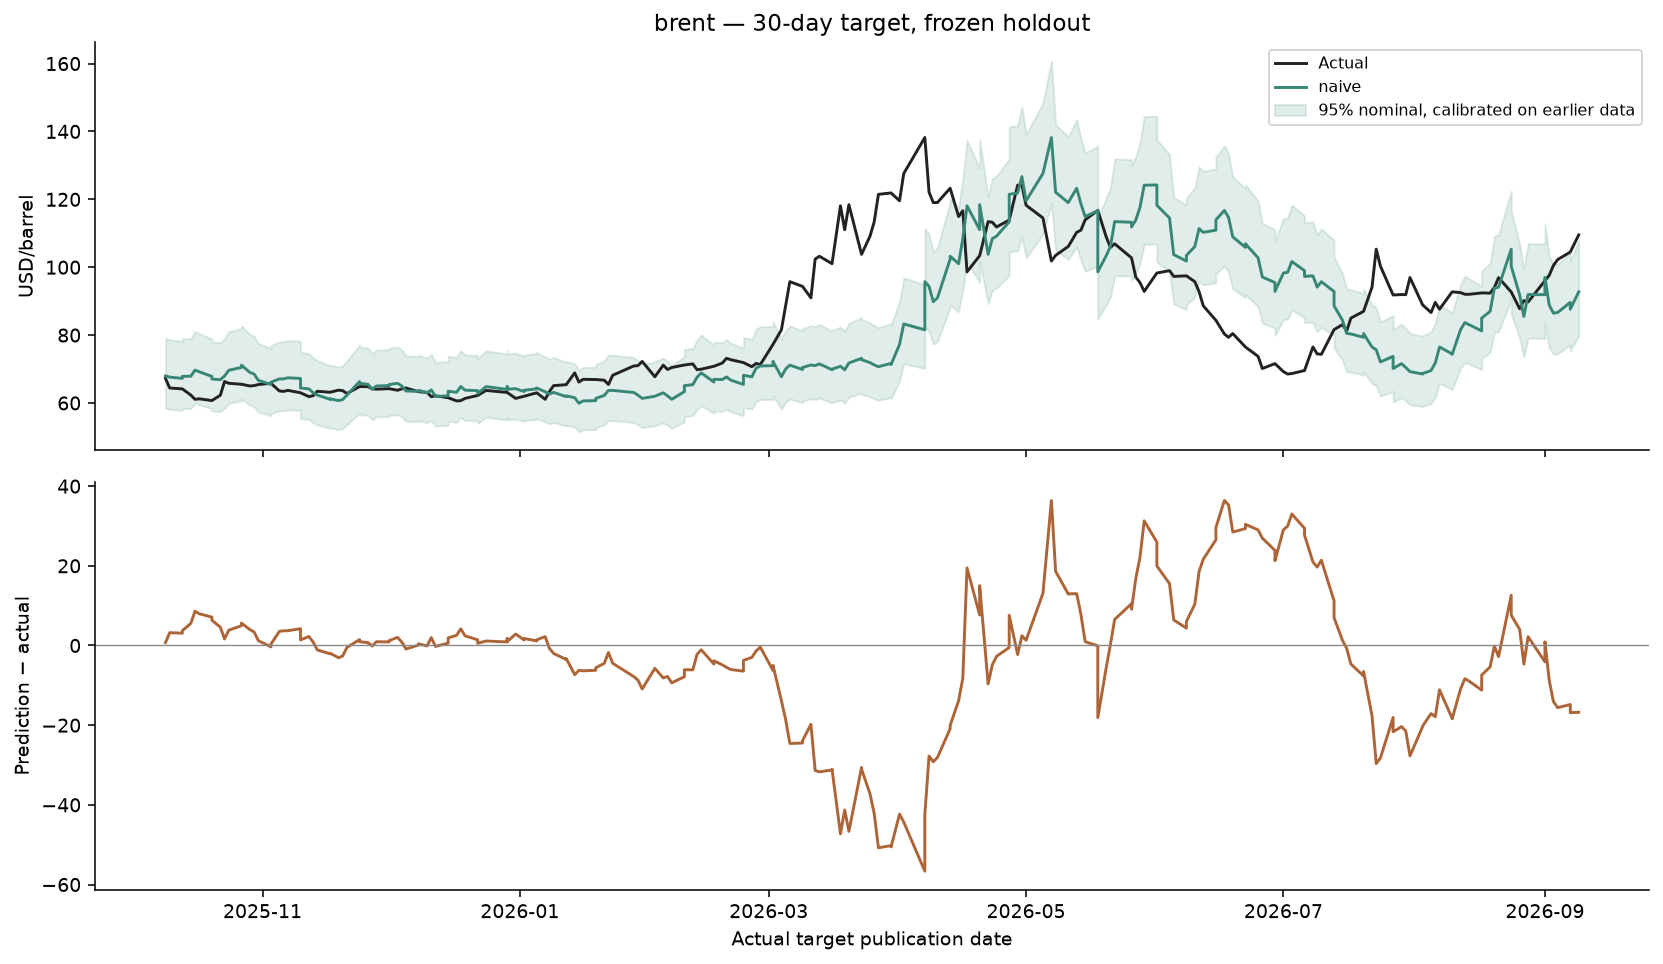

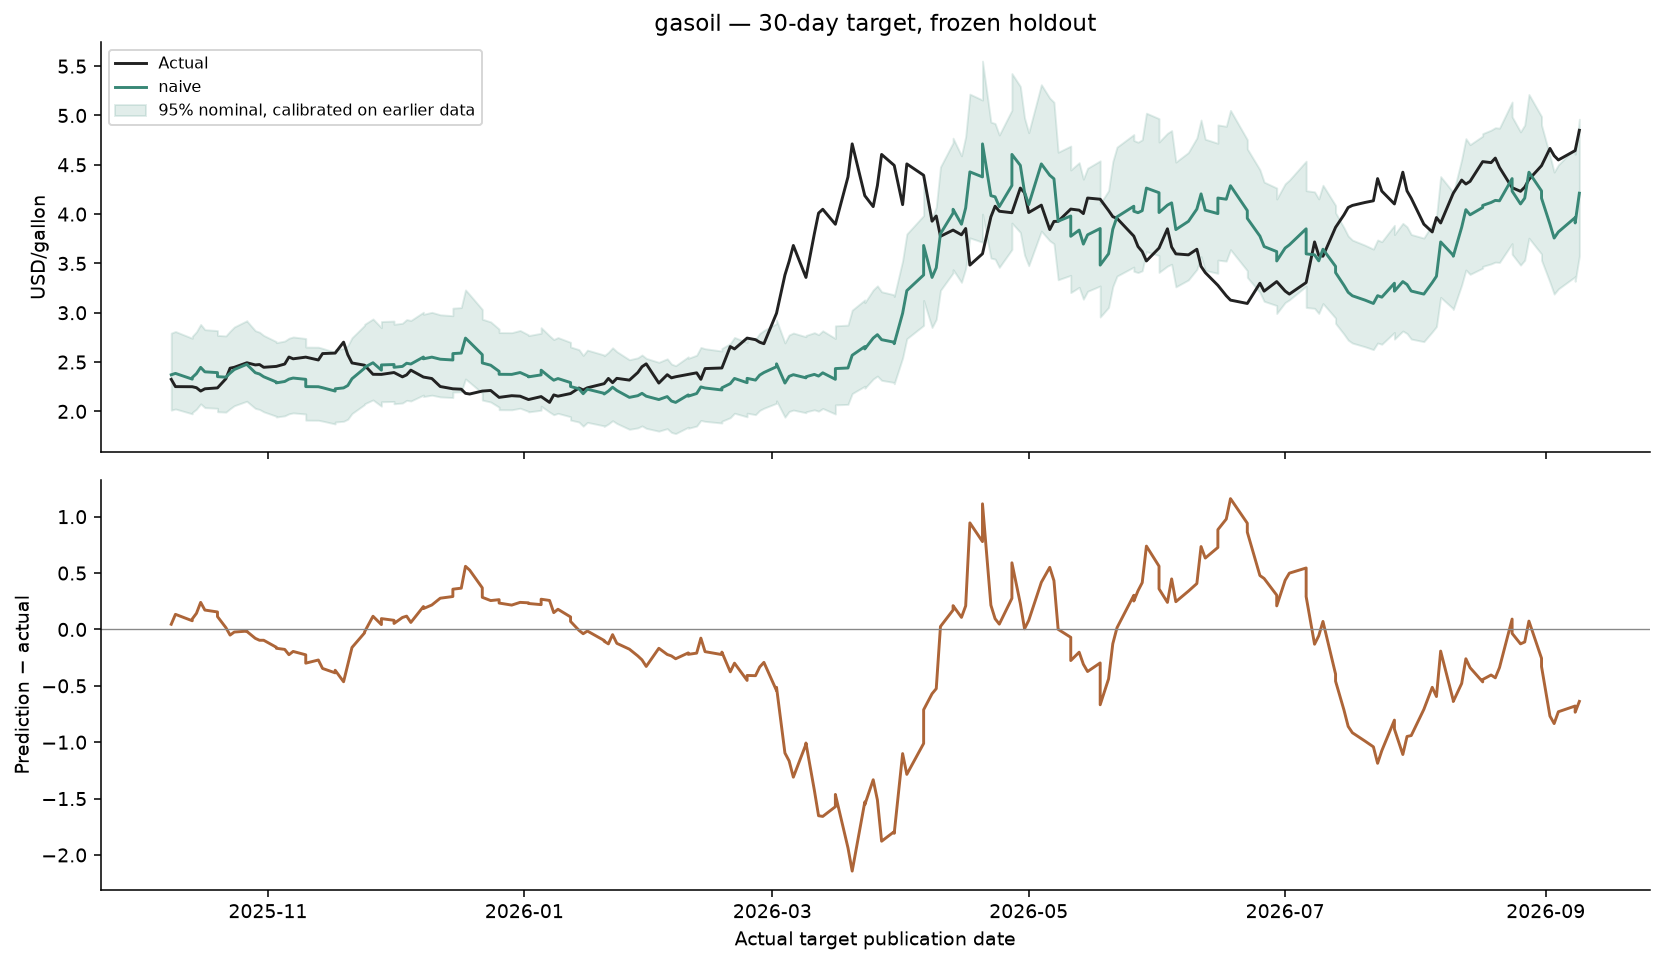

In [5]:
scores = pd.read_csv(REPORTS / 'holdout_metrics.csv')
selected = scores[scores.selected_on_validation].copy()
display(selected[['product', 'horizon_days', 'model', 'mae', 'rmse', 'mae_skill_vs_naive', 'interval_coverage']])
display(Image(filename=str(REPORTS / 'holdout_brent_30.png')))
display(Image(filename=str(REPORTS / 'holdout_gasoil_30.png')))

## 5. Interpretation

On the bundled snapshot, no complex candidate clears the required validation improvement consistently, so persistence remains selected for all product/horizon pairs. This is a useful negative result: feature richness does not by itself prove forecast value. Holdout scores for all candidates remain diagnostics and are not used to revise selection.

Read the generated report for metric definitions, split dates, feature-importance caveats, data-vintage limitations, bitumen exclusions, and deployment monitoring guidance.

In [6]:
display(Markdown((REPORTS / 'report.md').read_text(encoding='utf-8')))

# Data science audit and results

Generated from the local snapshot **2021-09-10 → 2026-09-09**, 1287 rows.
SHA-256: `98aa047ab90dfec93ab188f50c79fd33b4b60188047560b6f132458ebb12aa26`. Full versions, split dates and code fingerprints: [manifest.json](manifest.json).

## Findings and corrections

- The original notebook had partial execution, no engineered features, and no ML comparison. Its purported next-observation baseline was a single-origin constant prediction across 60 observations; it now uses rolling one-step persistence.
- The live Holt implementation damped its accumulated forecast trend twice. The geometric sum is corrected. Missing calendar days now advance model state without creating observations; validation uses the same calendar-day horizons as the API.
- The live forecast now reports persistence skill, empirical interval coverage, forecast origin, and data age. Its residual-based bands are explicitly heuristic, not validated confidence guarantees.
- Raw/processed local CSV agreement, missingness, finite positive prices, date uniqueness and chronology are checked before fitting. Local consistency does not authenticate the upstream provider or resolve historical revisions.

## Feature engineering and evaluation

Features cover lagged log returns, price/rolling-mean ratios, momentum, volatility, calendar cycles, gap length, and strictly earlier observations of the other product. Rolling windows count observations. Own price at origin is assumed published; cross-product features older than seven days are missing. Targets are actual observed prices, never interpolated.

Each direct model predicts the first publication on or after 1, 7, 30 or 90 calendar days (at most four days late). The exact label date is recorded. This endpoint experiment differs from the live service's evaluation of all observed points inside a forecast window.

First 65%: development and expanding-window cross-validation. Next 15%: interval calibration. Last 20%: frozen final holdout. Training labels crossing a split boundary are purged. Imputation and scaling are fitted only on training folds. Boosting early stopping is disabled to avoid a random internal validation split. Candidates: persistence, corrected Holt, regularized linear regression (Ridge), histogram gradient boosting, and random forest. Hyperparameters and seed are fixed in source.

Selection uses validation MAE only, requiring at least 2% improvement over persistence. All candidate holdout scores are diagnostic; the holdout winner is not used to change the selection. Models stay frozen across calibration and holdout; baseline states use observations available at each origin, as real-time persistence does.

## Selected models: untouched holdout results

| product | horizon_days | model | mae | rmse | mae_skill_vs_naive | interval_coverage |
| --- | --- | --- | --- | --- | --- | --- |
| brent | 1 | naive | 2.3677 | 3.6559 | 0.0000 | 0.7905 |
| brent | 7 | naive | 5.4362 | 7.7109 | 0.0000 | 0.8715 |
| brent | 30 | naive | 12.4009 | 17.8250 | 0.0000 | 0.6609 |
| brent | 90 | naive | 23.8418 | 30.6490 | 0.0000 | 0.5236 |
| gasoil | 1 | naive | 0.0866 | 0.1252 | 0.0000 | 0.8554 |
| gasoil | 7 | naive | 0.1862 | 0.2548 | 0.0000 | 0.8618 |
| gasoil | 30 | naive | 0.4587 | 0.6310 | 0.0000 | 0.7293 |
| gasoil | 90 | naive | 0.7799 | 1.0459 | 0.0000 | 0.5661 |

MAE/RMSE use each product's own price unit; they must not be averaged across products. Positive skill means improvement over persistence; negative skill means worse. Interval coverage is a fraction. See [all model metrics](holdout_metrics.csv), [validation scores](cross_validation.csv), [split audit](split_audit.csv), and [predictions](holdout_predictions.csv).

## EDA and interpretation

Model diagnostics use development dates only (through 2024-12-05). Price/return distributions, rolling volatility, ACF, calendar seasonality, ADF/KPSS stationarity tests, aligned-return correlation and robust shock flags are included. ADF's null is a unit root; KPSS's null is level stationarity. Their assumptions and structural breaks limit conclusions. Warnings and bounded p-values are retained. Seasonal patterns are descriptive, not evidence of a repeatable trading effect.

Aligned-return correlation: **0.558**. Both products use exactly the same start/end dates for this calculation. Flagged shocks: **33**, automatically removed: **0**. Missing weekdays include holidays and must not all be called data failures.

![Prices and returns](eda_prices_returns.png)
![Volatility and autocorrelation](eda_volatility_acf.png)
![Correlation and seasonality](eda_correlation_seasonality.png)

Calibration-set permutation importance is saved in [feature_importance.csv](feature_importance.csv). It measures changes in log-return MAE, not causal effects. Correlated features can substitute for one another, so importance is not a feature-deletion rule.

## Limits and next decisions

- No ML model is automatically promoted to the live app. Review validation consistency, holdout skill, freshness and interval coverage before a separate deployment decision.
- Historical provider publication timestamps and vintages are unavailable. Source-date causality prevents mechanical future leakage, but a true as-of backtest requires release timestamps/revision history. Data imported into SQL uses reconstructed collection times; those cannot establish actual availability.
- Prices are market benchmarks. They omit executable quotes, transaction costs, freight, FX and supplier terms. No profitability or purchasing recommendation is inferred from forecast accuracy.
- Bitumen is excluded: no comparable daily transaction-price history is supplied. The monthly BLS index is a separate quantity and must not be relabeled as USD/tonne.
- Overlapping horizons and serial dependence mean fold errors are not independent. Calibration quantiles have a 95% nominal level; time-series dependence and regime changes remove exchangeability guarantees. Use measured holdout coverage.
- Check fresh-data errors, missingness, feature ranges and interval coverage after deployment; reassess on new chronological data, not by repeatedly tuning to this holdout. Use block-bootstrap uncertainty or non-overlapping evaluation when more history is available.
- Serialized models, if requested, are research artifacts fitted on development only, with their training cutoff in each model card. Never load untrusted pickle/joblib files. Baseline artifacts contain `model=None` and an explicit baseline name.

## References

- [scikit-learn: lagged features and time-series validation](https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html)
- [Forecasting: Principles and Practice — damped Holt equations](https://otexts.com/fpp3/holt.html)
- [scikit-learn: permutation importance](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)
